<a href="https://colab.research.google.com/github/Samikhxnn/House-price-prediction/blob/main/ML_week1_(house_price_prediction)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#uploading the file to colab

In [ ]:
from google.colab import files
x=files.upload()

Saving HOUSE PRICE DETAILS.csv to HOUSE PRICE DETAILS.csv


#importing all libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import sklearn modules and functions

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
from sklearn.linear_model import LinearRegression

#Basic data cleaning

In [ ]:
df=pd.read_csv("HOUSE PRICE DETAILS.csv")

In [ ]:
#checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#droping duplicate rows(for practice)
df.drop_duplicates(inplace=True)

In [ ]:
#checking for null values
df.isnull().sum()

,0
house_id,0
area_sqft,0
lot_size,0
bedrooms,0
bathrooms,0
floors,0
age_years,0
location,0
distance_to_city_km,0
furnishing_status,0


In [ ]:
#filling null value
df["power_backup"]=df["power_backup"].fillna("unknown")


In [ ]:
#(only for practice) droping rows with null values
df.dropna(inplace=True)

#performing EDA

In [ ]:
df.head()

,house_id,area_sqft,lot_size,bedrooms,bathrooms,floors,age_years,location,distance_to_city_km,furnishing_status,property_type,balcony_count,facing_direction,water_supply_type,power_backup,society_rating,builder_rating,renovation_status,crime_rate,price
0,1,1360,4174,5,2,2,16,Rural,24.00,Fully-Furnished,Independent House,3,South,Borewell,Partial,3.7,4.4,Not Renovated,3.91,6203888
1,2,4272,7862,2,2,2,6,Rural,25.76,Semi-Furnished,Villa,3,North,Both,unknown,3.6,1.8,Recently Renovated,3.91,23122634
2,3,3592,4078,2,1,3,20,Urban,8.02,Semi-Furnished,Apartment,3,South,Borewell,Full,3.9,1.3,Not Renovated,4.14,24381331
3,4,966,2052,1,4,2,19,Rural,28.86,Unfurnished,Independent House,1,South,Municipal,unknown,2.1,3.8,Not Renovated,4.49,1708880
4,5,4926,7796,5,3,3,25,Rural,6.71,Unfurnished,Independent House,1,North,Municipal,unknown,2.3,2.6,Renovated,1.68,22178091


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   house_id             600 non-null    int64  
 1   area_sqft            600 non-null    int64  
 2   lot_size             600 non-null    int64  
 3   bedrooms             600 non-null    int64  
 4   bathrooms            600 non-null    int64  
 5   floors               600 non-null    int64  
 6   age_years            600 non-null    int64  
 7   location             600 non-null    object 
 8   distance_to_city_km  600 non-null    float64
 9   furnishing_status    600 non-null    object 
 10  property_type        600 non-null    object 
 11  balcony_count        600 non-null    int64  
 12  facing_direction     600 non-null    object 
 13  water_supply_type    600 non-null    object 
 14  power_backup         600 non-null    object 
 15  society_rating       600 non-null    flo

In [ ]:
df.describe()

,house_id,area_sqft,lot_size,bedrooms,bathrooms,floors,age_years,distance_to_city_km,balcony_count,society_rating,builder_rating,crime_rate,price
count,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02
mean,300.500000,2799.62500,4479.765000,2.988333,2.446667,1.965000,14.665000,15.526950,1.516667,2.972500,3.008667,2.845817,1.945140e+07
std,173.349358,1268.80981,2033.559439,1.413575,1.132531,0.803025,8.768366,8.280621,1.091654,1.172897,1.148633,1.312901,1.195946e+07
min,1.000000,504.00000,803.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.520000,-6.771400e+04
25%,150.750000,1666.75000,2837.250000,2.000000,1.000000,1.000000,7.000000,8.275000,1.000000,1.900000,2.100000,1.717500,1.057421e+07
50%,300.500000,2885.50000,4323.500000,3.000000,2.000000,2.000000,14.500000,15.715000,2.000000,3.000000,3.000000,2.965000,1.648580e+07
75%,450.250000,3842.25000,6234.000000,4.000000,3.000000,3.000000,22.000000,22.405000,2.000000,4.000000,4.000000,4.002500,2.726259e+07
max,600.000000,4999.00000,7996.000000,5.000000,4.000000,3.000000,29.000000,29.920000,3.000000,5.000000,5.000000,4.990000,6.343278e+07


In [ ]:
df.shape

(600, 20)

In [ ]:
df.size

12000

Text(0.5, 1.0, 'price per area ')

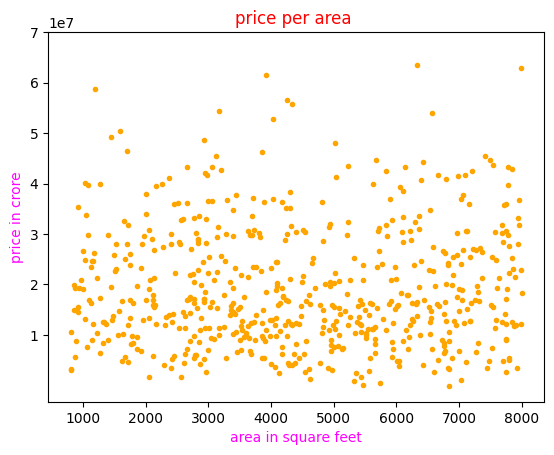

In [ ]:
# visualising the dataset
plt.scatter(df["lot_size"],df["price"],color=("orange"),marker=".")
plt.yticks([10000000,20000000,30000000,40000000,50000000,60000000,70000000])
plt.ylabel("price in crore",color="magenta")
plt.xlabel("area in square feet",color="magenta")
plt.title("price per area ",color="red")

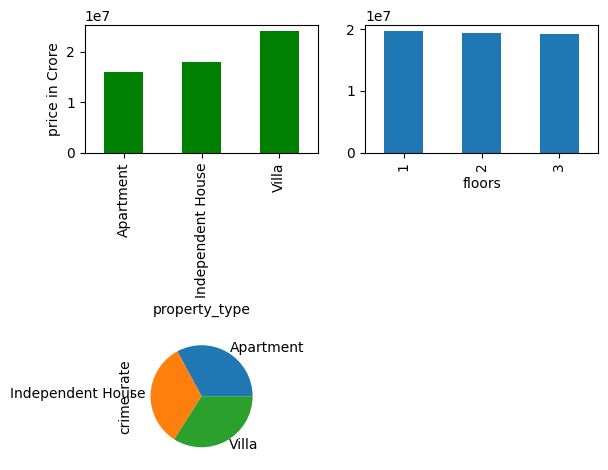

In [ ]:
plt.subplot(2,2,1)
df.groupby("property_type")["price"].mean().plot.bar(color="g")
plt.ylabel("price in Crore")
plt.subplot(2,2,2)
df.groupby("floors")["price"].mean().plot.bar()
plt.subplot(2,2,3)
df.groupby("property_type")["crime_rate"].mean().plot.pie()
plt.tight_layout()

# training the model

In [ ]:
df.columns

Index(['house_id', 'area_sqft', 'lot_size', 'bedrooms', 'bathrooms', 'floors',
       'age_years', 'location', 'distance_to_city_km', 'furnishing_status',
       'property_type', 'balcony_count', 'facing_direction',
       'water_supply_type', 'power_backup', 'society_rating', 'builder_rating',
       'renovation_status', 'crime_rate', 'price'],
      dtype='object')

In [ ]:
x=df[['area_sqft', 'lot_size', 'bedrooms', 'bathrooms', 'floors',
       'age_years', 'location', 'distance_to_city_km', 'furnishing_status',
       'property_type', 'balcony_count', 'facing_direction',
       'water_supply_type', 'power_backup', 'society_rating', 'builder_rating',
       'renovation_status', 'crime_rate']]
y=df["price"]

In [ ]:
#spliting the data into test and train splits
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.2,
                                               random_state=21, shuffle = False)


In [ ]:
# seperating numerical and categorical features for column tranformer
num_features=['area_sqft', 'lot_size', 'bedrooms', 'bathrooms', 'floors',
       'age_years', 'distance_to_city_km','balcony_count',
        'society_rating', 'builder_rating',
       'crime_rate']
cat_features=[ 'location','furnishing_status',
       'property_type','facing_direction',
       'water_supply_type', 'power_backup',
       'renovation_status']

In [ ]:
# creating pipeline
num_pipeline=Pipeline([("scaler",StandardScaler())])
cat_pipeline=Pipeline([("ohe",OneHotEncoder(handle_unknown="ignore")) ])
preprocessor=ColumnTransformer([
                                ("num",num_pipeline,num_features),
                                ("cat",cat_pipeline,cat_features)
                                ])
pipe=Pipeline([
                ("pre",preprocessor),( "model",LinearRegression())
])


In [ ]:
#training the model
pipe.fit(x_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['area_sqft', 'lot_size',
                                                   'bedrooms', 'bathrooms',
                                                   'floors', 'age_years',
                                                   'distance_to_city_km',
                                                   'balcony_count',
                                                   'society_rating',
                                                   'builder_rating',
                                                   'crime_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location',
                                                   'furnishing_status',
                                                   'property_type',
                                                   'facing_direction',
                                                   'water_supply_type',
                                                   'power_backup',
                                                   'renovation_status'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred=pipe.predict(x_test)
print(y_pred[0:3])
print("-"*10)
print(y_test[0:3])

[48281934.37770779 12623515.86396913  4140689.59438098]
----------
480    58820142
481     9719636
482     6367445
Name: price, dtype: int64


In [ ]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)
r=r2_score(y_test,y_pred)
print(r)
mse=mean_squared_error(y_test,y_pred)
print(mse)

2505126.7584135015
0.9170217618769104
11992463555155.01
